In [3]:
%load_ext autoreload
%autoreload 2

In [63]:
group_sizes = [
    2,
    5,
    5,
    11,
    2,
    2,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    3,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    19,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
    7,
]

variables_dict = {
    'TEN': 'Tenure',
    'HHL': 'Household Language',
    'VEH': 'Vehicles avaiable',
    'HINCP': 'Household Income (Thousands of USD)',
    'AGEP': 'Age (in years)',
    'SEX': 'Sex',
    'R65': 'Persons 65 years ≤',
    'R18': 'Persons ≤18 years',
    'SCHL': 'Education',
}

In [35]:
# Imports
import torch
import pandas as pd
import os 
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from vae import GroupHardMax
from finetuner import get_matching_indices


# Data Handling

In [ ]:
# Read state data
# Get pums_data and marginals
data_name = "one_hot_pNaNs_agep.csv"
pums_data = pd.read_csv(f"/workspace/data/{data_name}")
pums_np = pums_data.to_numpy()

# Read marginals
with open("marginals.json") as f:
    marginals = json.load(f)

# Read predictions data and make one-hot
prediction_folder = '/workspace/finetuned_models/predictions/' # Get path

prediction_paths = os.listdir(prediction_folder)
prediction_path = prediction_folder + prediction_paths[0]

predictions_torch = torch.load(prediction_path) # Load
predictions_unchanged = predictions_torch.detach().cpu().numpy()


hardmax = GroupHardMax(group_sizes) # Make one-hot
predictions_onehot = hardmax(predictions_torch)
predictions = predictions_onehot.detach().cpu().numpy()

# Get marginals for predicted, predicted_cheating and state data
matching_indices =get_matching_indices(marginals, list(pums_data.columns))

# Get marginal values for the predictions:
predicted_marginals = {}
for var, indices in matching_indices.items():
    predicted_marginals[var] = predictions[:, indices].mean()

# Get marginal values without performing one-hot encoding
predicted_marginals_cheat = {}
for var, indices in matching_indices.items():
    predicted_marginals_cheat[var] = predictions_unchanged[:, indices].mean()
    
# Get state marginals
state_marginals = {}
for var, indices in matching_indices.items():
    state_marginals[var] = pums_np[:, indices].mean()

# Recreate Figure 10

In [111]:
def plot_vars_bars(variables, legend=False, figsize= (10,5), bbox_to_anchor = (1,1)):
    num_keys_per_variable = []
    num_keys = 0
    for v in variables:
        # Count how many keys match v
        keys_v = [k for k in predicted_marginals.keys() if k.startswith(v)]
        num_keys_per_variable.append(len(keys_v))
        num_keys += len(keys_v)

    fig = plt.figure(figsize=figsize)  # Overall size; adjust as needed

    # Create a 1-row, len(variables)-column grid,
    # with column widths proportional to the number of categories
    gs = GridSpec(1, len(variables), width_ratios=num_keys_per_variable, wspace=0.4)

    axes = []
    for i in range(len(variables)):
        if i == 0:
            ax = fig.add_subplot(gs[i])  # first subplot
        else:
            ax = fig.add_subplot(gs[i])
            ax.sharey(axes[0])          # share y-axis with first subplot
        axes.append(ax)

    for i, v in enumerate(variables):
        ax = axes[i]
        
        # Get keys & data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals[k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Positions for bars
        x = np.arange(len(keys))
        width = 0.2

        # Plot grouped bars
        axes[i].bar(x,                 state_marginals_v, width=width, label='State Marginals')
        axes[i].bar(x + width,         pred_marginals_v,  width=width, label='Synthetic Marginals')
        axes[i].bar(x + 2 * width,     gt_marginals_v,    width=width, label='Groundtruth Marginals')

        # Nicely align ticks
        axes[i].set_xticks(x + width)
        axes[i].set_xticklabels([k.removeprefix(v + ':') for k in keys], rotation=90)

        # Give the bars a bit of left-right padding
        axes[i].set_xlim([-0.5, len(keys)])

        axes[i].set_title(variables_dict[v])

    if legend:
        fig.legend(*axes[0].get_legend_handles_labels(),
            loc='upper right', bbox_to_anchor=bbox_to_anchor)


    plt.show()

In [109]:
predicted_marginals = predicted_marginals_cheat

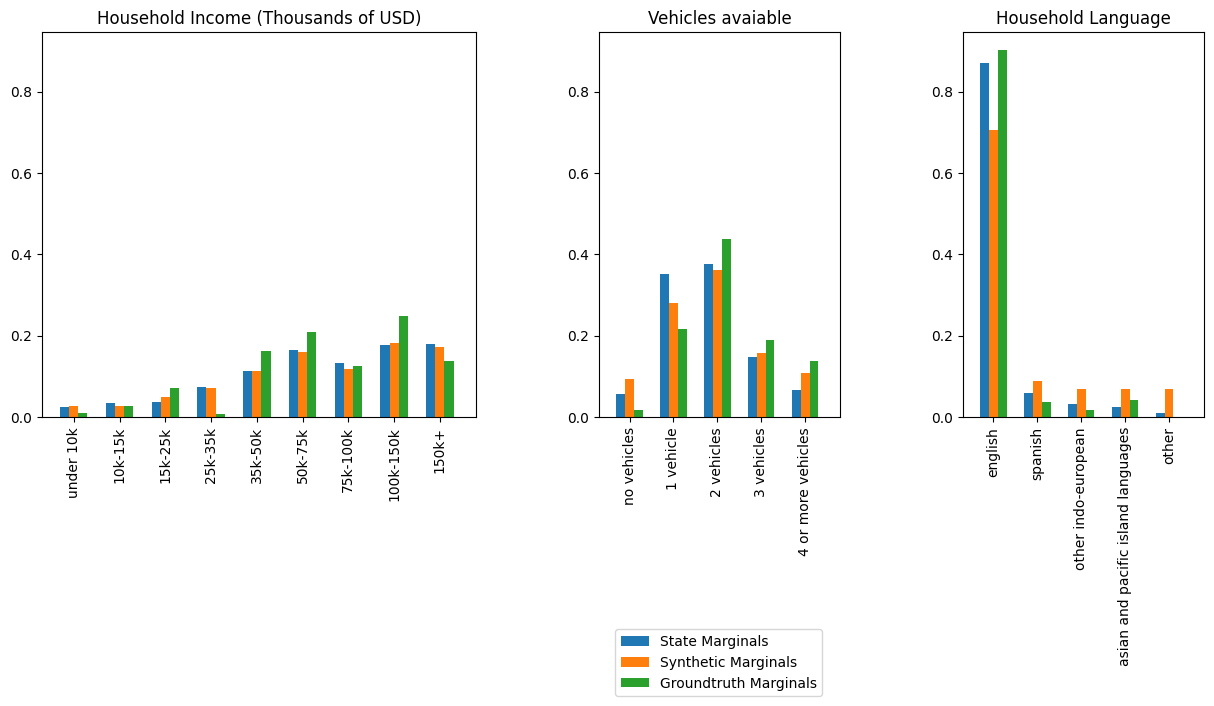

In [112]:
plot_vars_bars(['HINCP', 'VEH', 'HHL'], legend=True, figsize = (15,5), bbox_to_anchor = (0.65, -0.3))

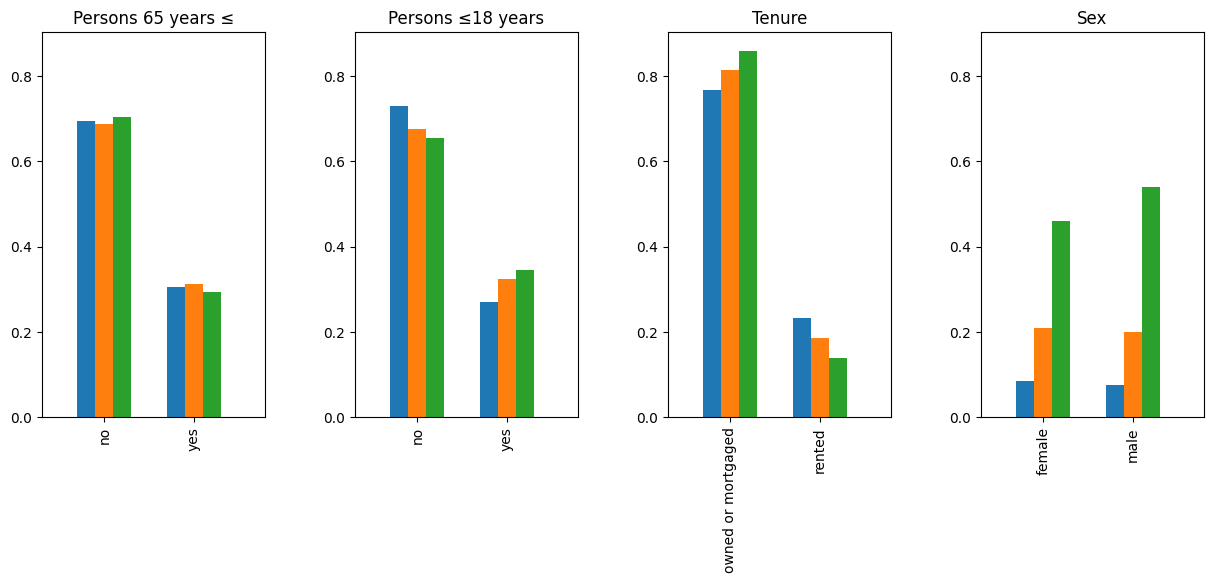

In [113]:
plot_vars_bars(['R65', 'R18', 'TEN', 'SEX'], legend=False, figsize = (15,5))

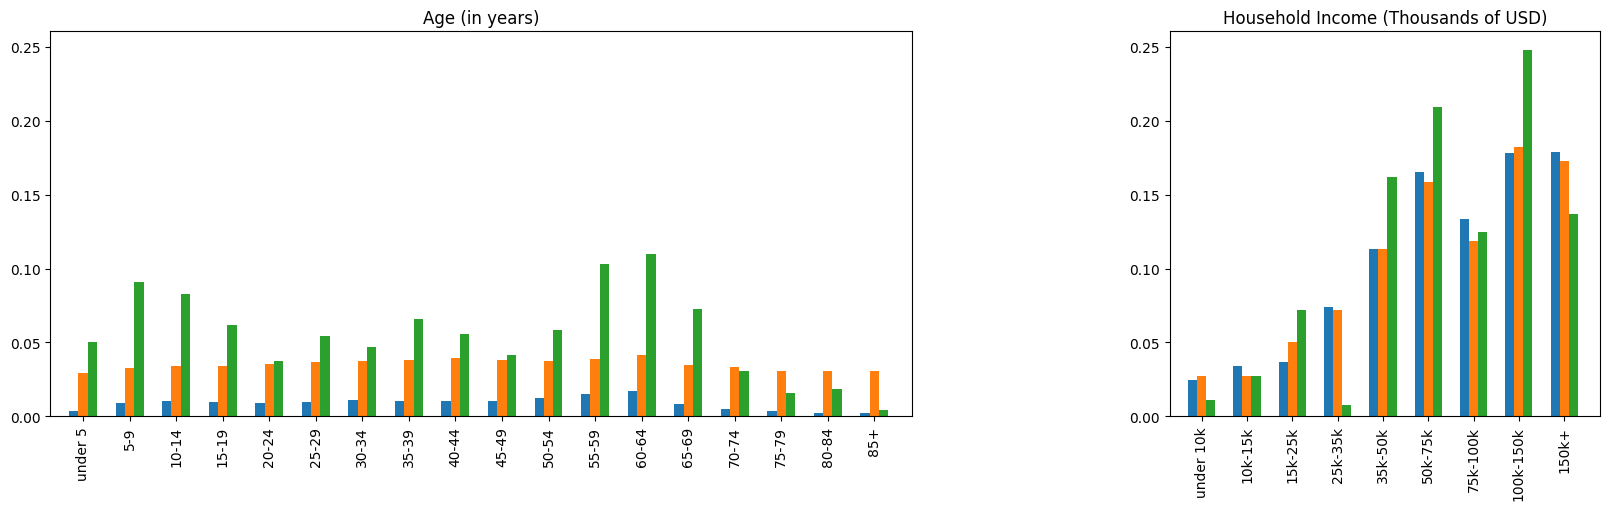

In [114]:
plot_vars_bars(['AGEP', 'HINCP',], legend=False, figsize = (20,5))

In [115]:
v = 'AGEP'

keys = [k for k in marginals.keys() if k.startswith(v)]
state_marginals_v = [state_marginals    [k] for k in keys]
pred_marginals_v  = [predicted_marginals[k] for k in keys]
gt_marginals_v    = [marginals[k] for k in keys]

In [120]:
sum(state_marginals_v)

0.16036781781406848

In [121]:
sum(pred_marginals_v)

0.6324704103171825

In [125]:
state_marginals = {}
for var, indices in matching_indices.items():
    print(var)
    state_marginals[var] = pums_np[:, indices].mean()

TEN:owned or mortgaged
TEN:rented
HHL:english
HHL:spanish
HHL:other indo-european
HHL:asian and pacific island languages
HHL:other
VEH:no vehicles
VEH:1 vehicle
VEH:2 vehicles
VEH:3 vehicles
VEH:4 or more vehicles
HINCP:under 10k
HINCP:10k-15k
HINCP:15k-25k
HINCP:25k-35k
HINCP:35k-50k
HINCP:50k-75k
HINCP:75k-100k
HINCP:100k-150k
HINCP:150k+
R65:no
R65:yes
R18:no
R18:yes
AGEP:under 5
AGEP:5-9
AGEP:10-14
AGEP:15-19
AGEP:20-24
AGEP:25-29
AGEP:30-34
AGEP:35-39
AGEP:40-44
AGEP:45-49
AGEP:50-54
AGEP:55-59
AGEP:60-64
AGEP:65-69
AGEP:70-74
AGEP:75-79
AGEP:80-84
AGEP:85+
SEX:female
SEX:male
SCHL:less than high school
SCHL:high school
SCHL:college or associate
SCHL:bachelor
SCHL:graduate


In [129]:
pums_data.columns

Index(['TEN:owned or mortgaged', 'TEN:rented', 'HHL:english', 'HHL:spanish',
       'HHL:other indo-european', 'HHL:asian and pacific island languages',
       'HHL:other', 'VEH:no vehicles', 'VEH:1 vehicle', 'VEH:2 vehicles',
       ...
       'SCHL_13:bachelor', 'SCHL_13:graduate', 'SCHL_13:nan', 'SCHL_14:other',
       'SCHL_14:less than high school', 'SCHL_14:high school',
       'SCHL_14:college or associate', 'SCHL_14:bachelor', 'SCHL_14:graduate',
       'SCHL_14:nan'],
      dtype='object', length=433)

In [134]:
v = 'AGEP'
vals_dict = {var:pums_data[:,i].mean() for i, var in enumerate(pums_data.columns) if var.startswith(v)}
vals_dict

InvalidIndexError: (slice(None, None, None), 69)

In [122]:
sum(gt_marginals_v)

1.0